# 🧬 Exploratory Data Analysis (EDA): Phage-Host Interaction Datasets

This notebook explores **Dataset A (`PhageHostLearn`)** and **Dataset B (`KlebPhaCol`)** used for evaluating **Fine-Tuning vs. Retraining from Scratch** in phage-host interaction (PHI) prediction.

### Objectives
1. Inspect dataset schemas, columns, dimensions, and data types.
2. Analyze class imbalance (positive infection vs. non-infection pairs).
3. Visualize phage host range and bacterial host susceptibility distributions.
4. Explore capsular K-locus diversity.
5. Project ESM-2 protein language embeddings into 2D PCA space.
6. Verify Train (80%) vs. Test (20%) split distributions.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA

# Set styling
sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams.update({"font.size": 11, "figure.autolayout": True})

BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data"
DIR_A = DATA_DIR / "dataset_A_phagehostlearn"
DIR_B = DATA_DIR / "dataset_B_klebphacol"
FIG_DIR = BASE_DIR / "results" / "figures"
print("Base directory:", BASE_DIR)

Base directory: /Volumes/TRANSCEND/Projects/VinUni/finetune_vs_retrain


## 1. Schema & Dataset Dimensions
We load interaction matrices, metadata tables, and ESM-2 embedding shapes for both datasets.

In [2]:
df_inter_a = pd.read_csv(DIR_A / "standardized_interactions.csv", index_col=0)
df_phage_a = pd.read_csv(DIR_A / "phage_metadata.csv")
df_host_a = pd.read_csv(DIR_A / "host_metadata.csv")
df_rbp_a = pd.read_csv(DIR_A / "esm2_embeddings_rbp.csv")
df_loci_a = pd.read_csv(DIR_A / "esm2_embeddings_loci.csv")

print("=== Dataset A (PhageHostLearn) Overview ===")
print(f"  Interactions Matrix Shape : {df_inter_a.shape} (Hosts x Phages)")
print(f"  Phage Metadata Count      : {len(df_phage_a)} phages")
print(f"  Host Metadata Count       : {len(df_host_a)} host strains")
print(f"  RBP Embeddings Shape      : {df_rbp_a.shape} (RBPs x ESM2 Features)")
print(f"  Loci Embeddings Shape     : {df_loci_a.shape} (Loci x ESM2 Features)")

df_host_b = pd.read_csv(DIR_B / "host_metadata.csv")
df_loci_b = pd.read_csv(DIR_B / "esm2_embeddings_loci_invitro.csv")
print("\n=== Dataset B (KlebPhaCol) Overview ===")
print(f"  Host Strains Evaluated    : {len(df_host_b)} host strains")
print(f"  Loci Embeddings Shape     : {df_loci_b.shape}")

=== Dataset A (PhageHostLearn) Overview ===
  Interactions Matrix Shape : (215, 132) (Hosts x Phages)
  Phage Metadata Count      : 132 phages
  Host Metadata Count       : 215 host strains
  RBP Embeddings Shape      : (274, 1282) (RBPs x ESM2 Features)
  Loci Embeddings Shape     : (200, 1281) (Loci x ESM2 Features)

=== Dataset B (KlebPhaCol) Overview ===
  Host Strains Evaluated    : 30 host strains
  Loci Embeddings Shape     : (30, 1281)


## 2. Class Imbalance Analysis
Biological interaction datasets often exhibit high sparsity or class imbalance.

,Dataset,Class,Count,Percentage
0,Dataset A,Positive,465,1.638478
1,Dataset A,Negative,27915,98.361522
2,Dataset B,Positive,2100,66.666667
3,Dataset B,Negative,1050,33.333333


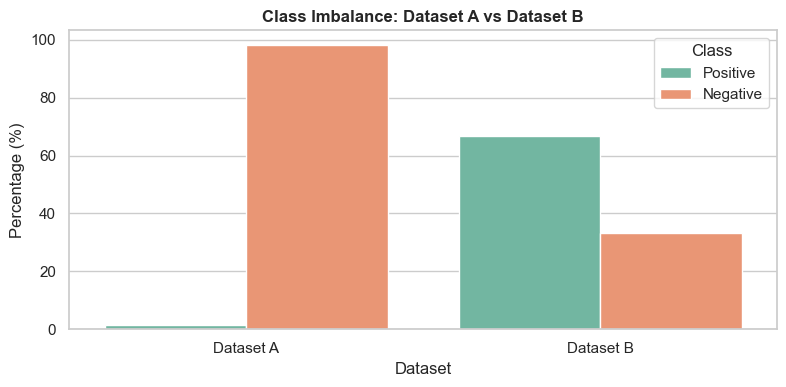

In [3]:
vals_a = df_inter_a.values.flatten()
vals_a = vals_a[~np.isnan(vals_a)]
pos_a, neg_a = int((vals_a > 0).sum()), int((vals_a == 0).sum())

data_b_feat = np.load(BASE_DIR / "features" / "phagehostlearn" / "dataset_B_features.npz")
y_b = data_b_feat["y"]
pos_b, neg_b = int((y_b > 0).sum()), int((y_b == 0).sum())

df_imbalance = pd.DataFrame([
    {"Dataset": "Dataset A", "Class": "Positive", "Count": pos_a, "Percentage": pos_a/len(vals_a)*100},
    {"Dataset": "Dataset A", "Class": "Negative", "Count": neg_a, "Percentage": neg_a/len(vals_a)*100},
    {"Dataset": "Dataset B", "Class": "Positive", "Count": pos_b, "Percentage": pos_b/len(y_b)*100},
    {"Dataset": "Dataset B", "Class": "Negative", "Count": neg_b, "Percentage": neg_b/len(y_b)*100},
])

display(df_imbalance)

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=df_imbalance, x="Dataset", y="Percentage", hue="Class", palette="Set2")
plt.title("Class Imbalance: Dataset A vs Dataset B", fontweight="bold")
plt.ylabel("Percentage (%)")
plt.show()

## 3. Phage Host Range & Host Susceptibility Distributions
We calculate the number of susceptible host strains per phage and number of infecting phages per host strain.

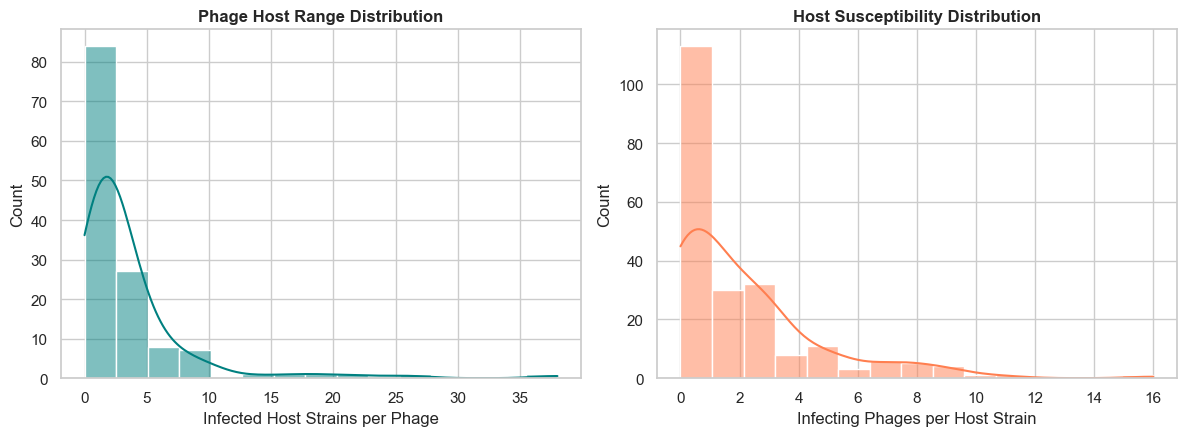

In [4]:
phage_host_range = (df_inter_a > 0).sum(axis=0)
host_susceptibility = (df_inter_a > 0).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(phage_host_range, kde=True, ax=axes[0], color="teal", bins=15)
axes[0].set_title("Phage Host Range Distribution", fontweight="bold")
axes[0].set_xlabel("Infected Host Strains per Phage")

sns.histplot(host_susceptibility, kde=True, ax=axes[1], color="coral", bins=15)
axes[1].set_title("Host Susceptibility Distribution", fontweight="bold")
axes[1].set_xlabel("Infecting Phages per Host Strain")
plt.show()

## 4. Capsular K-Locus Diversity
Exploring the distribution of K-locus capsular types.

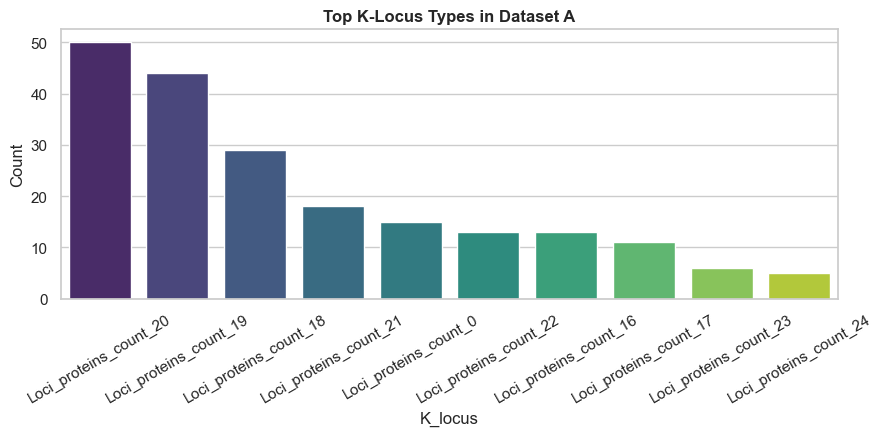

In [5]:
top_kloci = df_host_a["K_locus"].value_counts().head(10).reset_index()
top_kloci.columns = ["K_locus", "Count"]

plt.figure(figsize=(9, 4.5))
sns.barplot(data=top_kloci, x="K_locus", y="Count", hue="K_locus", palette="viridis", legend=False)
plt.title("Top K-Locus Types in Dataset A", fontweight="bold")
plt.xticks(rotation=30)
plt.show()

## 5. ESM-2 Embedding Space Projection (PCA)
Visualizing 1,280-dimensional ESM-2 protein language embeddings projected onto 2D space.

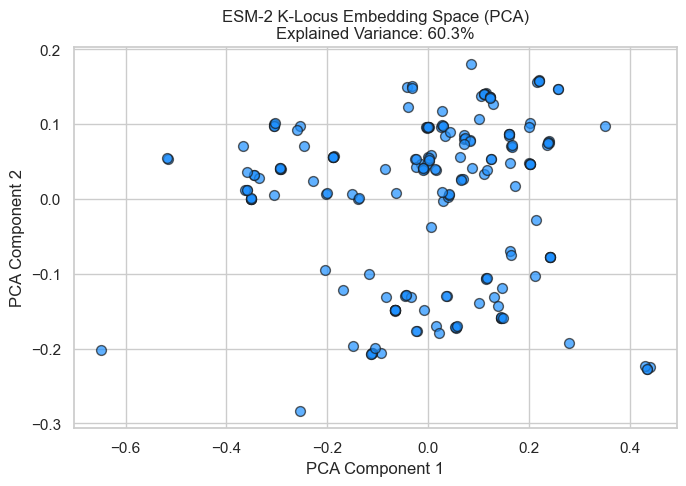

In [6]:
feat_cols = [c for c in df_loci_a.columns if c != "accession"]
X_loci = df_loci_a[feat_cols].values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_loci)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c="dodgerblue", alpha=0.7, edgecolors="k", s=50)
plt.title(f"ESM-2 K-Locus Embedding Space (PCA)\nExplained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

## 6. Train (80%) vs. Test (20%) Split Distribution
Verifying interaction sample counts between training and test sets.

In [7]:
with open(BASE_DIR / "data" / "klebphacol_train_indices.json") as f:
    tr_idx = json.load(f)
with open(BASE_DIR / "data" / "klebphacol_test_indices.json") as f:
    te_idx = json.load(f)

y_tr = y_b[tr_idx]
y_te = y_b[te_idx]

print(f"Train Split Pairwise Interactions : {len(tr_idx)} ({len(tr_idx)/len(y_b)*100:.1f}%)")
print(f"Test Split Pairwise Interactions  : {len(te_idx)} ({len(te_idx)/len(y_b)*100:.1f}%)")
print(f"Train Positives                   : {(y_tr > 0).sum()} / {len(tr_idx)}")
print(f"Test Positives                    : {(y_te > 0).sum()} / {len(te_idx)}")

Train Split Pairwise Interactions : 2520 (80.0%)
Test Split Pairwise Interactions  : 630 (20.0%)
Train Positives                   : 1470 / 2520
Test Positives                    : 630 / 630
